#### Importing required libraries

In [81]:
import matplotlib.pyplot as plt 
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
import seaborn as sns
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_rows', None)

In [82]:
df_posts_by_time_cut = pd.read_csv('germanwings_crash_posts_by_time_cut.csv').sort_values(by='time_cut',ascending=False)

# Convert time_cut from minutes to hours
df_posts_by_time_cut["time_cut_hours"] = df_posts_by_time_cut["time_cut"] / 60

# Calculate imbalance rate
df_posts_by_time_cut["imbalance_rate"] = df_posts_by_time_cut["rumours"] / (
    df_posts_by_time_cut["rumours"] + df_posts_by_time_cut["no_rumours"]
)

# 30% dataset threshold
threshold_hour = round(
    df_posts_by_time_cut[df_posts_by_time_cut.post <= df_posts_by_time_cut['post'].max() * 0.3]['time_cut_hours'].max(),
    2
)

# Number of posts at 30% threshold
posts = int(
    df_posts_by_time_cut[df_posts_by_time_cut.post <= df_posts_by_time_cut['post'].max() * 0.3]['post'].max()
)

#### Example of split for Germanwings Crash dataset
* 30% of fine tune training data at 1.77 hours after event started  with 255 posts


In [83]:
import plotly.graph_objects as go

# Create figure with secondary Y-axis
fig = go.Figure()

# Left Y-axis: Imbalance rate
fig.add_trace(go.Scatter(
    x=df_posts_by_time_cut["time_cut_hours"],
    y=df_posts_by_time_cut["imbalance_rate"],
    name="True Rumour Rate",
    yaxis="y1",
    mode="lines",
    line=dict(color="purple")
))

# Right Y-axis: Number of posts
fig.add_trace(go.Scatter(
    x=df_posts_by_time_cut["time_cut_hours"],
    y=df_posts_by_time_cut["post"],
    name="Number of Posts",
    yaxis="y2",
    mode="lines",
    line=dict(color="orange")
))

# Add vertical line for 30% threshold
fig.add_shape(
    type="line",
    x0=threshold_hour,
    x1=threshold_hour,
    y0=0,
    y1=1,
    yref="paper",
    line=dict(color="green", dash="dash")
)

# Add annotation: number of posts at 30%
fig.add_annotation(
    y=0.95,
    x=3,
    yref="paper",
    text=f"30% of Dataset: {posts} posts",
    showarrow=True,
    arrowhead=1,
    ax=40,
    ay=0,
    font=dict(color="black")
)

# Add annotation: time of 30% threshold
fig.add_annotation(
    y=0.85,
    x=3,
    yref="paper",
    text=f"{threshold_hour} hours after the event started",
    showarrow=True,
    arrowhead=1,
    ax=40,
    ay=0,
    font=dict(color="black")
)

# Update layout with axis and text styling
fig.update_layout(
    title="Imbalance Rate and Number of Posts Over Time",
    font=dict(size=16),  # <-- This sets a larger base font size
    xaxis=dict(
        title="Time (Hours)",
        titlefont=dict(color="black", size=18),
        tickfont=dict(color="black", size=14)
    ),
    yaxis=dict(
        title="True Rumour Rate",
        range=[0, 1],
        titlefont=dict(color="black", size=18),
        tickfont=dict(color="black", size=14)
    ),
    yaxis2=dict(
        title="Number of Posts",
        overlaying="y",
        side="right",
        titlefont=dict(color="black", size=18),
        tickfont=dict(color="black", size=14)
    ),
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.25,
        xanchor="center",
        x=0.5,
        font=dict(size=14)
    ),
    template="plotly_white",
    width=900,
    height=500
)


fig.show()


#### Loading datasets statistics to get the final time cut 
* **The initial  time cut will be 10 minutes after the first post publication**
*  **The final time cut will be equal to 6 hours after the publication of last post**

In [84]:
df_posts_by_time_cut_gw = pd.read_csv('germanwings_crash_posts_by_time_cut.csv')
df_posts_by_time_cut_gw['new_posts_cum_sum'] = df_posts_by_time_cut_gw.new_posts.cumsum()
max_time_cut_gw = int(df_posts_by_time_cut_gw[df_posts_by_time_cut_gw.new_posts_cum_sum==int(df_posts_by_time_cut_gw.new_posts_cum_sum.max())]\
                   .time_cut.min())+(60*6)

df_posts_by_time_cut_ows = pd.read_csv('ottawa_shooting_posts_by_time_cut.csv')
df_posts_by_time_cut_ows['new_posts_cum_sum'] = df_posts_by_time_cut_ows.new_posts.cumsum()
max_time_cut_ows = int(df_posts_by_time_cut_ows[df_posts_by_time_cut_ows.new_posts_cum_sum==int(df_posts_by_time_cut_ows.new_posts_cum_sum.max())]\
                   .time_cut.min())+(60*6)


df_posts_by_time_cut_ss = pd.read_csv('sydneysiege_posts_by_time_cut.csv')
df_posts_by_time_cut_ss['new_posts_cum_sum'] = df_posts_by_time_cut_ss.new_posts.cumsum()
max_time_cut_ss = int(df_posts_by_time_cut_ss[df_posts_by_time_cut_ss.new_posts_cum_sum==int(df_posts_by_time_cut_ss.new_posts_cum_sum.max())]\
                   .time_cut.min())+(60*6)

df_posts_by_time_cut_fe = pd.read_csv('ferguson_posts_by_time_cut.csv')
df_posts_by_time_cut_fe['new_posts_cum_sum'] = df_posts_by_time_cut_fe.new_posts.cumsum()
max_time_cut_fe = int(df_posts_by_time_cut_fe[df_posts_by_time_cut_fe.new_posts_cum_sum==int(df_posts_by_time_cut_fe.new_posts_cum_sum.max())]\
                   .time_cut.min())+(60*6)

### Transfer Learning - GAT Network

In [85]:
experiment = mlflow.get_experiment_by_name('GAT Network 2025-10-18 German Wings Crash TF')
experiment_id = experiment.experiment_id
df_gat_gw = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
df_gat_gw = df_gat_gw.merge(df_posts_by_time_cut_gw,left_on='metrics.time_cut', right_on='time_cut')
df_gat_gw['metrics.time_cut'] = df_gat_gw['metrics.time_cut'].astype('int')
df_gat_gw['time_cut_hours'] = round(df_gat_gw['time_cut']/60,2)
df_gat_gw = df_gat_gw[df_gat_gw['metrics.time_cut']<=max_time_cut_gw]


experiment = mlflow.get_experiment_by_name('GAT Network 2025-10-18 Ottawa Shooting TF')
experiment_id = experiment.experiment_id
df_gat_ows = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
df_gat_ows = df_gat_ows.merge(df_posts_by_time_cut_ows,left_on='metrics.time_cut', right_on='time_cut')
df_gat_ows['metrics.time_cut'] = df_gat_ows['metrics.time_cut'].astype('int')
df_gat_ows['time_cut_hours'] = round(df_gat_ows['time_cut']/60,2)
df_gat_ows = df_gat_ows[df_gat_ows['metrics.time_cut']<=max_time_cut_ows]


experiment = mlflow.get_experiment_by_name('GAT Network 2025-10-18 Sydney Siege TF')
experiment_id = experiment.experiment_id
df_gat_ss = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
df_gat_ss = df_gat_ss.merge(df_posts_by_time_cut_ss,left_on='metrics.time_cut', right_on='time_cut')
df_gat_ss['metrics.time_cut'] = df_gat_ss['metrics.time_cut'].astype('int')
df_gat_ss['time_cut_hours'] = round(df_gat_ss['time_cut']/60,2)
df_gat_ss = df_gat_ss[df_gat_ss['metrics.time_cut']<=max_time_cut_ss]


experiment = mlflow.get_experiment_by_name('GAT Network 2025-10-19 Ferguson TF')
experiment_id = experiment.experiment_id
df_gat_fe = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
#df_gat_fe = df_gat_fe.merge(df_posts_by_time_cut,left_on='metrics.time_cut', right_on='time_cut')
df_gat_fe['metrics.time_cut'] = df_gat_fe['metrics.time_cut'].astype('int')
df_gat_fe['time_cut_hours'] = round(df_gat_fe['metrics.time_cut']/60,2)
df_gat_fe = df_gat_fe[df_gat_fe['metrics.time_cut']<=max_time_cut_fe]

In [86]:
df_gat_fe['model']='GAT'
df_gat_fe['dataset']='ferguson'

df_gat_ss['dataset']='sydney_siege'
df_gat_ss['model']='GAT'

df_gat_ows['dataset']='ottawa_shooting'
df_gat_ows['model']='GAT'

df_gat_gw['dataset']='germanwings_crash'
df_gat_gw['model']='GAT'


### Transfer Learning - Han Network

In [87]:
experiment = mlflow.get_experiment_by_name('Han Network 2025-10-18 German Wings Crash TF')
experiment_id = experiment.experiment_id
df_han_gw = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
df_han_gw = df_han_gw.merge(df_posts_by_time_cut_gw,left_on='metrics.time_cut', right_on='time_cut')
df_han_gw['metrics.time_cut'] = df_han_gw['metrics.time_cut'].astype('int')
df_han_gw['time_cut_hours'] = round(df_han_gw['time_cut']/60,2)
df_han_gw = df_han_gw[df_han_gw['metrics.time_cut']<=max_time_cut_gw]


experiment = mlflow.get_experiment_by_name('Han Network 2025-10-18 Ottawa Shooting TF')
experiment_id = experiment.experiment_id
df_han_ows = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
df_han_ows = df_han_ows.merge(df_posts_by_time_cut_ows,left_on='metrics.time_cut', right_on='time_cut')
df_han_ows['metrics.time_cut'] = df_han_ows['metrics.time_cut'].astype('int')
df_han_ows['time_cut_hours'] = round(df_han_ows['time_cut']/60,2)
df_han_ows = df_han_ows[df_han_ows['metrics.time_cut']<=max_time_cut_ows]


experiment = mlflow.get_experiment_by_name('Han Network 2025-10-18 Sydney Siege TF')
experiment_id = experiment.experiment_id
df_han_ss = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
df_han_ss = df_han_ss.merge(df_posts_by_time_cut_ss,left_on='metrics.time_cut', right_on='time_cut')
df_han_ss['metrics.time_cut'] = df_han_ss['metrics.time_cut'].astype('int')
df_han_ss['time_cut_hours'] = round(df_han_ss['time_cut']/60,2)
df_han_ss = df_han_ss[df_han_ss['metrics.time_cut']<=max_time_cut_ss]


experiment = mlflow.get_experiment_by_name('Han Network 2025-10-18 Ferguson TF')
experiment_id = experiment.experiment_id
df_han_fe = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
df_han_fe = df_han_fe.merge(df_posts_by_time_cut_fe,left_on='metrics.time_cut', right_on='time_cut')
df_han_fe['metrics.time_cut'] = df_han_fe['metrics.time_cut'].astype('int')
df_han_fe['time_cut_hours'] = round(df_han_fe['time_cut']/60,2)
df_han_fe = df_han_fe[df_han_fe['metrics.time_cut']<=max_time_cut_fe]

In [88]:
df_han_fe['model']='HAN'
df_han_fe['dataset']='ferguson'

df_han_ss['dataset']='sydney_siege'
df_han_ss['model']='HAN'

df_han_ows['dataset']='ottawa_shooting'
df_han_ows['model']='HAN'

df_han_gw['dataset']='germanwings_crash'
df_han_gw['model']='HAN'


#### LSTM 

In [89]:
experiment = mlflow.get_experiment_by_name('LSTM  2025-10-19 German Wings TF')
experiment_id = experiment.experiment_id
df_lstm_gw = mlflow.search_runs(experiment_ids=[experiment_id])#.dropna(subset='metrics.final_test_auc')



df_lstm_gw = df_lstm_gw.merge(df_posts_by_time_cut_gw,left_on='metrics.time_cut', right_on='time_cut')
df_lstm_gw['metrics.time_cut'] = df_lstm_gw['metrics.time_cut'].astype('int')
df_lstm_gw['time_cut_hours'] = round(df_lstm_gw['time_cut']/60,2)
df_lstm_gw = df_lstm_gw[df_lstm_gw['metrics.time_cut']<=max_time_cut_gw]


experiment = mlflow.get_experiment_by_name('LSTM  2025-10-19 Ottawa Shooting TF')
experiment_id = experiment.experiment_id
df_lstm_ows = mlflow.search_runs(experiment_ids=[experiment_id])
df_lstm_ows = df_lstm_ows.merge(df_posts_by_time_cut_ows,left_on='metrics.time_cut', right_on='time_cut')
df_lstm_ows['metrics.time_cut'] = df_lstm_ows['metrics.time_cut'].astype('int')
df_lstm_ows['time_cut_hours'] = round(df_lstm_ows['time_cut']/60,2)
df_lstm_ows = df_lstm_ows[df_lstm_ows['metrics.time_cut']<=max_time_cut_ows]


experiment = mlflow.get_experiment_by_name('LSTM  2025-10-20 Sydney Siege TF')
experiment_id = experiment.experiment_id
df_lstm_ss = mlflow.search_runs(experiment_ids=[experiment_id])
df_lstm_ss = df_lstm_ss.merge(df_posts_by_time_cut_ss,left_on='metrics.time_cut', right_on='time_cut')
df_lstm_ss['metrics.time_cut'] = df_lstm_ss['metrics.time_cut'].astype('int')
df_lstm_ss['time_cut_hours'] = round(df_lstm_ss['time_cut']/60,2)
df_lstm_ss = df_lstm_ss[df_lstm_ss['metrics.time_cut']<=max_time_cut_ss]


experiment = mlflow.get_experiment_by_name('LSTM  2025-10-20 Feguson TF')
experiment_id = experiment.experiment_id
df_lstm_fe = mlflow.search_runs(experiment_ids=[experiment_id])
df_lstm_fe = df_lstm_fe.merge(df_posts_by_time_cut_fe,left_on='metrics.time_cut', right_on='time_cut')
df_lstm_fe['metrics.time_cut'] = df_lstm_fe['metrics.time_cut'].astype('int')
df_lstm_fe['time_cut_hours'] = round(df_lstm_fe['time_cut']/60,2)
df_lstm_fe = df_lstm_fe[df_lstm_fe['metrics.time_cut']<=max_time_cut_fe]

In [90]:
df_lstm_fe['model']='LSTM'
df_lstm_fe['dataset']='ferguson'

df_lstm_ss['dataset']='sydney_siege'
df_lstm_ss['model']='LSTM'

df_lstm_ows['dataset']='ottawa_shooting'
df_lstm_ows['model']='LSTM'

df_lstm_gw['dataset']='germanwings_crash'
df_lstm_gw['model']='LSTM'


#### Light GBM 

In [91]:

experiment = mlflow.get_experiment_by_name('Light Gbm  2025-10-18  German Wings Crash TF')
experiment_id = experiment.experiment_id
df_lgb_gw = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
df_lgb_gw = df_lgb_gw.merge(df_posts_by_time_cut_gw,left_on='metrics.time_cut', right_on='time_cut')
df_lgb_gw['metrics.time_cut'] = df_lgb_gw['metrics.time_cut'].astype('int')
df_lgb_gw['time_cut_hours'] = round(df_lgb_gw['time_cut']/60,2)
df_lgb_gw = df_lgb_gw[df_lgb_gw['metrics.time_cut']<=max_time_cut_gw]


experiment = mlflow.get_experiment_by_name('Light Gbm  2025-10-18  Ottawa Shooting TF')
experiment_id = experiment.experiment_id
df_lgb_ows = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
df_lgb_ows = df_lgb_ows.merge(df_posts_by_time_cut_ows,left_on='metrics.time_cut', right_on='time_cut')
df_lgb_ows['metrics.time_cut'] = df_lgb_ows['metrics.time_cut'].astype('int')
df_lgb_ows['time_cut_hours'] = round(df_lgb_ows['time_cut']/60,2)
df_lgb_ows = df_lgb_ows[df_lgb_ows['metrics.time_cut']<=max_time_cut_ows]


experiment = mlflow.get_experiment_by_name('Light Gbm  2025-10-18  Sydney Siege TF')
experiment_id = experiment.experiment_id
df_lgb_ss = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
df_lgb_ss = df_lgb_ss.merge(df_posts_by_time_cut_ss,left_on='metrics.time_cut', right_on='time_cut')
df_lgb_ss['metrics.time_cut'] = df_lgb_ss['metrics.time_cut'].astype('int')
df_lgb_ss['time_cut_hours'] = round(df_lgb_ss['time_cut']/60,2)
df_lgb_ss = df_lgb_ss[df_lgb_ss['metrics.time_cut']<=max_time_cut_ss]

experiment = mlflow.get_experiment_by_name('Light Gbm  2025-10-18  Ferguson TF')
experiment_id = experiment.experiment_id
df_lgb_fe = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
df_lgb_fe = df_lgb_fe.merge(df_posts_by_time_cut_fe,left_on='metrics.time_cut', right_on='time_cut')
df_lgb_fe['metrics.time_cut'] = df_lgb_fe['metrics.time_cut'].astype('int')
df_lgb_fe['time_cut_hours'] = round(df_lgb_fe['time_cut']/60,2)
df_lgb_fe = df_lgb_fe[df_lgb_fe['metrics.time_cut']<=max_time_cut_fe]

In [92]:
df_lgb_fe['model']='Light Gbm'
df_lgb_fe['dataset']='ferguson'

df_lgb_ss['dataset']='sydney_siege'
df_lgb_ss['model']='Light Gbm'

df_lgb_ows['dataset']='ottawa_shooting'
df_lgb_ows['model']='Light Gbm'

df_lgb_gw['dataset']='germanwings_crash'
df_lgb_gw['model']='Light Gbm'



#### Random Forest

In [93]:

experiment = mlflow.get_experiment_by_name('Random Forest  2025-10-18  German Wings TF')
experiment_id = experiment.experiment_id
df_rf_gw = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
df_rf_gw = df_rf_gw.merge(df_posts_by_time_cut_gw,left_on='metrics.time_cut', right_on='time_cut')
df_rf_gw['metrics.time_cut'] = df_rf_gw['metrics.time_cut'].astype('int')
df_rf_gw['time_cut_hours'] = round(df_rf_gw['time_cut']/60,2)
df_rf_gw = df_rf_gw[df_rf_gw['metrics.time_cut']<=max_time_cut_gw]


experiment = mlflow.get_experiment_by_name('Random Forest  2025-10-18  Ottawa Shooting TF')
experiment_id = experiment.experiment_id
df_rf_ows = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
df_rf_ows = df_rf_ows.merge(df_posts_by_time_cut_ows,left_on='metrics.time_cut', right_on='time_cut')
df_rf_ows['metrics.time_cut'] = df_rf_ows['metrics.time_cut'].astype('int')
df_rf_ows['time_cut_hours'] = round(df_rf_ows['time_cut']/60,2)
df_rf_ows = df_rf_ows[df_rf_ows['metrics.time_cut']<=max_time_cut_ows]


experiment = mlflow.get_experiment_by_name('Random Forest  2025-10-18  Sydney Siege TF')
experiment_id = experiment.experiment_id
df_rf_ss = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
df_rf_ss = df_rf_ss.merge(df_posts_by_time_cut_ss,left_on='metrics.time_cut', right_on='time_cut')
df_rf_ss['metrics.time_cut'] = df_rf_ss['metrics.time_cut'].astype('int')
df_rf_ss['time_cut_hours'] = round(df_rf_ss['time_cut']/60,2)
df_rf_ss = df_rf_ss[df_rf_ss['metrics.time_cut']<=max_time_cut_ss]

experiment = mlflow.get_experiment_by_name('Random Forest  2025-10-18  Ferguson TF')
experiment_id = experiment.experiment_id
df_rf_fe = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
df_rf_fe = df_rf_fe.merge(df_posts_by_time_cut_fe,left_on='metrics.time_cut', right_on='time_cut')
df_rf_fe['metrics.time_cut'] = df_rf_fe['metrics.time_cut'].astype('int')
df_rf_fe['time_cut_hours'] = round(df_rf_fe['time_cut']/60,2)
df_rf_fe = df_rf_fe[df_rf_fe['metrics.time_cut']<=max_time_cut_fe]

In [94]:
df_rf_fe['model']='Random Forest'
df_rf_fe['dataset']='ferguson'

df_rf_ss['dataset']='sydney_siege'
df_rf_ss['model']='Random Forest'

df_rf_ows['dataset']='ottawa_shooting'
df_rf_ows['model']='Random Forest'

df_rf_gw['dataset']='germanwings_crash'
df_rf_gw['model']='Random Forest'


#### Creating a single dataframe with all experiments

In [95]:

df_all_tl=  pd.concat([df_rf_fe,df_rf_ss,df_rf_ows,df_rf_gw,  df_gat_fe,df_gat_ss,df_gat_ows,df_gat_gw, \
                       df_lgb_fe,df_lgb_ss,df_lgb_ows,df_lgb_gw, df_han_fe,df_han_ss,df_han_ows,df_han_gw,\
                       df_lstm_fe, df_lstm_gw, df_lstm_ows,df_lstm_ss
                      ])

In [96]:
df_all_tl['metrics.final_f1'] = 2 * (
    df_all_tl['metrics.final_precision'] * df_all_tl['metrics.final_recall']
) / (
    df_all_tl['metrics.final_precision'] + df_all_tl['metrics.final_recall']
)


df_all_tl['metrics.final_f1'].fillna(0,inplace=True)

In [97]:
df_all_tl_grouped_auc = df_all_tl.groupby(['dataset', 'model'])['metrics.final_auc'].agg('mean').reset_index()
df_all_tl_grouped_recall = df_all_tl.groupby(['dataset', 'model'])['metrics.final_recall'].agg('mean').reset_index()


In [98]:
df_all_tl['metrics.f1'] = 2 * (
    df_all_tl['metrics.final_precision'] * df_all_tl['metrics.final_recall']
) / (
    df_all_tl['metrics.final_precision'] + df_all_tl['metrics.final_recall']
)


In [99]:
df_all_tl['metrics.curr_precision']= np.where(df_all_tl.new_posts==0,0,df_all_tl['metrics.curr_precision'])
df_all_tl['metrics.s.curr_recall']= np.where(df_all_tl.new_posts==0,0,df_all_tl['metrics.curr_recall'])
df_all_tl['metrics.curr_f1']= np.where(df_all_tl.new_posts==0,0, 2 * (df_all_tl['metrics.curr_precision'] * df_all_tl['metrics.curr_recall'])\
                                       / (df_all_tl['metrics.curr_precision'] + df_all_tl['metrics.curr_recall']))
df_all_tl['metrics.curr_f1'].fillna(0,inplace=True)

#### Final metrics by model and dataset

In [100]:
df_all_tl[df_all_tl.new_posts>0].groupby(['model', 'dataset'])[
    ['metrics.final_f1', 'metrics.final_precision', 'metrics.final_recall']
].agg('mean') \
.reset_index() \
.sort_values(by=['dataset', 'metrics.final_f1'], ascending=[True, False]).round(2)



,model,dataset,metrics.final_f1,metrics.final_precision,metrics.final_recall
3,HAN,ferguson,0.69,0.75,0.64
7,LSTM,ferguson,0.45,0.32,0.90
15,Random Forest,ferguson,0.40,0.74,0.29
11,Light Gbm,ferguson,0.12,0.88,0.07
4,HAN,germanwings_crash,0.61,0.62,0.61
0,GAT,germanwings_crash,0.59,0.60,0.59
8,LSTM,germanwings_crash,0.54,0.43,0.81
12,Light Gbm,germanwings_crash,0.47,0.42,0.55
16,Random Forest,germanwings_crash,0.46,0.40,0.60
5,HAN,ottawa_shooting,0.80,0.81,0.80


#### Metrics at the t0 (time of post publication)
Measuring early detection

In [101]:
df_all_tl[df_all_tl.new_posts>0].groupby(['model', 'dataset'])[
    ['metrics.curr_f1', 'metrics.curr_precision', 'metrics.curr_recall']
].agg('mean') \
.reset_index() \
.sort_values(by=['dataset', 'metrics.curr_recall'], ascending=[True, False]).round(2)



,model,dataset,metrics.curr_f1,metrics.curr_precision,metrics.curr_recall
7,LSTM,ferguson,0.04,0.03,0.11
15,Random Forest,ferguson,0.11,0.11,0.11
3,HAN,ferguson,0.08,0.08,0.08
11,Light Gbm,ferguson,0.00,0.00,0.00
8,LSTM,germanwings_crash,0.30,0.22,0.52
12,Light Gbm,germanwings_crash,0.36,0.34,0.45
16,Random Forest,germanwings_crash,0.29,0.29,0.42
4,HAN,germanwings_crash,0.15,0.15,0.17
0,GAT,germanwings_crash,0.09,0.08,0.11
9,LSTM,ottawa_shooting,0.65,0.63,0.69


In [102]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# Filter for the Ottawa Shooting dataset
df_filtered = df_all_tl[df_all_tl['dataset'] == 'sydney_siege'].copy()

# Ensure x-axis is sorted and numeric (or datetime), convert if necessary
# If time_cut_hours is numeric:
df_filtered['time_cut_hours'] = pd.to_numeric(df_filtered['time_cut_hours'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['time_cut_hours']).sort_values('time_cut_hours')

# Aggregate POST once per time_cut_hours (take first or mean — choose what makes sense)
df_post = (
    df_filtered.groupby('time_cut_hours', as_index=False)
               .agg({'post': 'first'})   # change 'first' to 'mean' if preferred
               .sort_values('time_cut_hours')
)

# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Plot Final F1 for each model on primary y-axis
models = df_filtered['model'].unique()
colors = ['red', 'green', 'purple', 'orange', 'blue', 'brown']  # extend if needed

for i, model in enumerate(models):
    df_model = df_filtered[df_filtered['model'] == model].sort_values('time_cut_hours')
    fig.add_trace(
        go.Scatter(
            x=df_model['time_cut_hours'],
            y=df_model['metrics.final_precision'],
            mode='lines+markers',
            name=str(model),
            line=dict(color=colors[i % len(colors)])
        ),
        secondary_y=False,
    )

# Add single POST line on secondary y-axis (right)
fig.add_trace(
    go.Scatter(
        x=df_post['time_cut_hours'],
        y=df_post['post'],
        mode='lines+markers',
        name='Post',
        line=dict(color='gray', width=3, dash='dash'),
        marker=dict(symbol='circle')
    ),
    secondary_y=True,
)

# Layout & axes
fig.update_layout(
    title="Time vs. Final F1 — Sydney Siege",
    title_x=0.5,
    template='plotly_white',
    width=1000,
    height=600,
    font=dict(size=14),
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5, font=dict(size=12))
)

fig.update_xaxes(title_text="Time (hours)")
fig.update_yaxes(title_text="Final F1 Score", range=[0, 1], secondary_y=False)
fig.update_yaxes(title_text="Post", secondary_y=True, showgrid=False)

fig.show()


#### F1 by hour, model and dataset
Measuring detection through time

In [103]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# Filter for the Ottawa Shooting dataset
df_filtered = df_all_tl[df_all_tl['dataset'] == 'ottawa_shooting'].copy()

# Ensure x-axis is sorted and numeric (or datetime), convert if necessary
# If time_cut_hours is numeric:
df_filtered['time_cut_hours'] = pd.to_numeric(df_filtered['time_cut_hours'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['time_cut_hours']).sort_values('time_cut_hours')

# Aggregate POST once per time_cut_hours (take first or mean — choose what makes sense)
df_post = (
    df_filtered.groupby('time_cut_hours', as_index=False)
               .agg({'post': 'first'})   # change 'first' to 'mean' if preferred
               .sort_values('time_cut_hours')
)

# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Plot Final F1 for each model on primary y-axis
models = df_filtered['model'].unique()
colors = ['red', 'green', 'purple', 'orange', 'blue', 'brown']  # extend if needed

for i, model in enumerate(models):
    df_model = df_filtered[df_filtered['model'] == model].sort_values('time_cut_hours')
    fig.add_trace(
        go.Scatter(
            x=df_model['time_cut_hours'],
            y=df_model['metrics.final_f1'],
            mode='lines+markers',
            name=str(model),
            line=dict(color=colors[i % len(colors)])
        ),
        secondary_y=False,
    )

# Add single POST line on secondary y-axis (right)
fig.add_trace(
    go.Scatter(
        x=df_post['time_cut_hours'],
        y=df_post['post'],
        mode='lines+markers',
        name='Post',
        line=dict(color='gray', width=3, dash='dash'),
        marker=dict(symbol='circle')
    ),
    secondary_y=True,
)

# Layout & axes
fig.update_layout(
    title="Time vs. Final F1 — Ottawa Shooting",
    title_x=0.5,
    template='plotly_white',
    width=1000,
    height=600,
    font=dict(size=14),
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5, font=dict(size=12))
)

fig.update_xaxes(title_text="Time (hours)")
fig.update_yaxes(title_text="Final F1 Score", range=[0, 1], secondary_y=False)
fig.update_yaxes(title_text="Post", secondary_y=True, showgrid=False)

fig.show()


In [104]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# Filter for the Ottawa Shooting dataset
df_filtered = df_all_tl[df_all_tl['dataset'] == 'germanwings_crash'].copy()

# Ensure x-axis is sorted and numeric (or datetime), convert if necessary
# If time_cut_hours is numeric:
df_filtered['time_cut_hours'] = pd.to_numeric(df_filtered['time_cut_hours'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['time_cut_hours']).sort_values('time_cut_hours')

# Aggregate POST once per time_cut_hours (take first or mean — choose what makes sense)
df_post = (
    df_filtered.groupby('time_cut_hours', as_index=False)
               .agg({'post': 'first'})   # change 'first' to 'mean' if preferred
               .sort_values('time_cut_hours')
)

# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Plot Final F1 for each model on primary y-axis
models = df_filtered['model'].unique()
colors = ['red', 'green', 'purple', 'orange', 'blue', 'brown']  # extend if needed

for i, model in enumerate(models):
    df_model = df_filtered[df_filtered['model'] == model].sort_values('time_cut_hours')
    fig.add_trace(
        go.Scatter(
            x=df_model['time_cut_hours'],
            y=df_model['metrics.final_f1'],
            mode='lines+markers',
            name=str(model),
            line=dict(color=colors[i % len(colors)])
        ),
        secondary_y=False,
    )

# Add single POST line on secondary y-axis (right)
fig.add_trace(
    go.Scatter(
        x=df_post['time_cut_hours'],
        y=df_post['post'],
        mode='lines+markers',
        name='Post',
        line=dict(color='gray', width=3, dash='dash'),
        marker=dict(symbol='circle')
    ),
    secondary_y=True,
)

# Layout & axes
fig.update_layout(
    title="Time vs. Final F1 — German Wings Crash",
    title_x=0.5,
    template='plotly_white',
    width=1000,
    height=600,
    font=dict(size=14),
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5, font=dict(size=12))
)

fig.update_xaxes(title_text="Time (hours)")
fig.update_yaxes(title_text="Final F1 Score", range=[0, 1], secondary_y=False)
fig.update_yaxes(title_text="Post", secondary_y=True, showgrid=False)

fig.show()


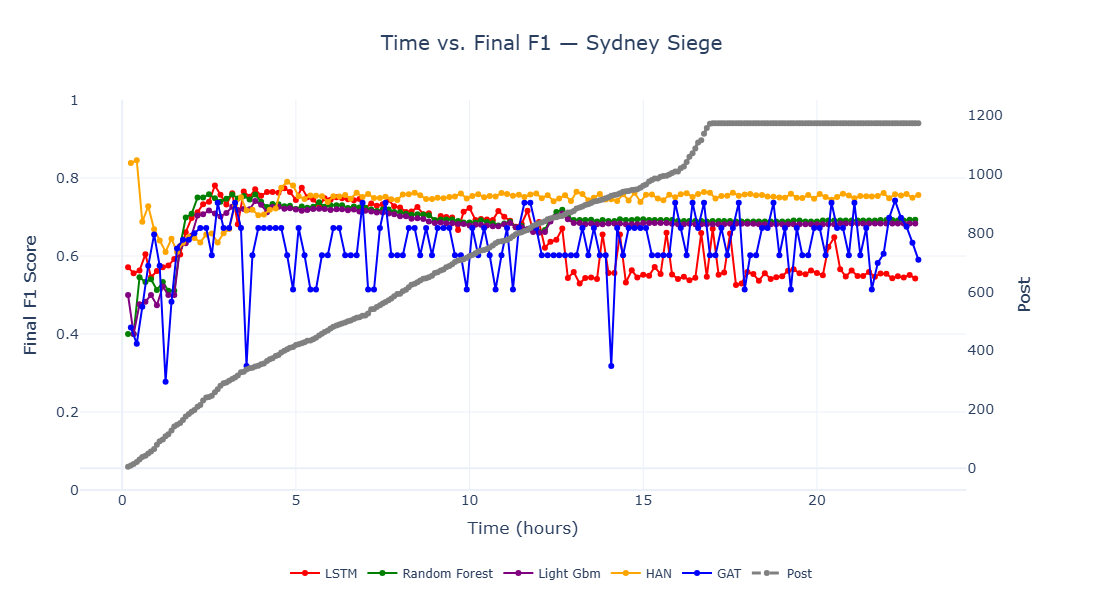

In [105]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# Filter for the Ottawa Shooting dataset
df_filtered = df_all_tl[df_all_tl['dataset'] == 'sydney_siege'].copy()

# Ensure x-axis is sorted and numeric (or datetime), convert if necessary
# If time_cut_hours is numeric:
df_filtered['time_cut_hours'] = pd.to_numeric(df_filtered['time_cut_hours'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['time_cut_hours']).sort_values('time_cut_hours')

# Aggregate POST once per time_cut_hours (take first or mean — choose what makes sense)
df_post = (
    df_filtered.groupby('time_cut_hours', as_index=False)
               .agg({'post': 'first'})   # change 'first' to 'mean' if preferred
               .sort_values('time_cut_hours')
)

# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Plot Final F1 for each model on primary y-axis
models = df_filtered['model'].unique()
colors = ['red', 'green', 'purple', 'orange', 'blue', 'brown']  # extend if needed

for i, model in enumerate(models):
    df_model = df_filtered[df_filtered['model'] == model].sort_values('time_cut_hours')
    fig.add_trace(
        go.Scatter(
            x=df_model['time_cut_hours'],
            y=df_model['metrics.final_f1'],
            mode='lines+markers',
            name=str(model),
            line=dict(color=colors[i % len(colors)])
        ),
        secondary_y=False,
    )

# Add single POST line on secondary y-axis (right)
fig.add_trace(
    go.Scatter(
        x=df_post['time_cut_hours'],
        y=df_post['post'],
        mode='lines+markers',
        name='Post',
        line=dict(color='gray', width=3, dash='dash'),
        marker=dict(symbol='circle')
    ),
    secondary_y=True,
)

# Layout & axes
fig.update_layout(
    title="Time vs. Final F1 — Sydney Siege",
    title_x=0.5,
    template='plotly_white',
    width=1000,
    height=600,
    font=dict(size=14),
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5, font=dict(size=12))
)

fig.update_xaxes(title_text="Time (hours)")
fig.update_yaxes(title_text="Final F1 Score", range=[0, 1], secondary_y=False)
fig.update_yaxes(title_text="Post", secondary_y=True, showgrid=False)

fig.show()


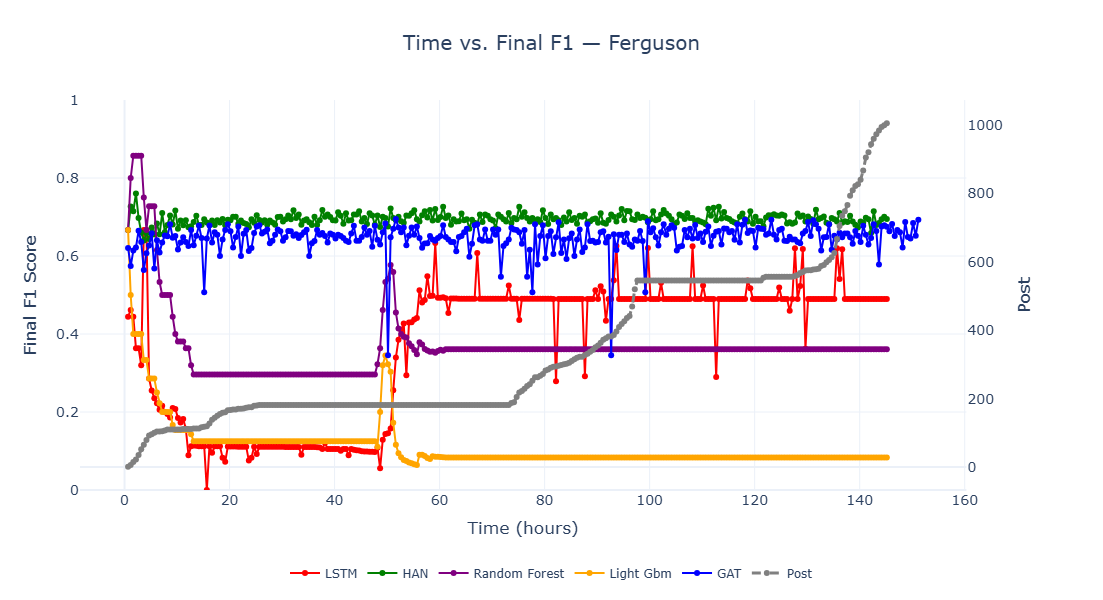

In [106]:
df_filtered = df_all_tl[df_all_tl['dataset'] == 'ferguson'].copy()

# Ensure x-axis is sorted and numeric (or datetime), convert if necessary
# If time_cut_hours is numeric:
df_filtered['time_cut_hours'] = pd.to_numeric(df_filtered['time_cut_hours'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['time_cut_hours']).sort_values('time_cut_hours')

# Aggregate POST once per time_cut_hours (take first or mean — choose what makes sense)
df_post = (
    df_filtered.groupby('time_cut_hours', as_index=False)
               .agg({'post': 'first'})   # change 'first' to 'mean' if preferred
               .sort_values('time_cut_hours')
)

# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Plot Final F1 for each model on primary y-axis
models = df_filtered['model'].unique()
colors = ['red', 'green', 'purple', 'orange', 'blue', 'brown']  # extend if needed

for i, model in enumerate(models):
    df_model = df_filtered[df_filtered['model'] == model].sort_values('time_cut_hours')
    fig.add_trace(
        go.Scatter(
            x=df_model['time_cut_hours'],
            y=df_model['metrics.final_f1'],
            mode='lines+markers',
            name=str(model),
            line=dict(color=colors[i % len(colors)])
        ),
        secondary_y=False,
    )

# Add single POST line on secondary y-axis (right)
fig.add_trace(
    go.Scatter(
        x=df_post['time_cut_hours'],
        y=df_post['post'],
        mode='lines+markers',
        name='Post',
        line=dict(color='gray', width=3, dash='dash'),
        marker=dict(symbol='circle')
    ),
    secondary_y=True,
)

# Layout & axes
fig.update_layout(
    title="Time vs. Final F1 — Ferguson",
    title_x=0.5,
    template='plotly_white',
    width=1000,
    height=600,
    font=dict(size=14),
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5, font=dict(size=12))
)

fig.update_xaxes(title_text="Time (hours)")
fig.update_yaxes(title_text="Final F1 Score", range=[0, 1], secondary_y=False)
fig.update_yaxes(title_text="Post", secondary_y=True, showgrid=False)

fig.show()
